# Gráficas de `ins_data.csv`

Posición y orientación del INS.
Columnas: `date`, `ref_id`, `pos_x`, `pos_y`, `pos_z`, `yaw`.

In [37]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('ins_data_prueba_20.csv', parse_dates=['date'])
print(f"{len(df)} filas | {df['date'].min()} -> {df['date'].max()}")
print('ref_id:', df['ref_id'].unique())
df.head()

2243 filas | 2026-08-03 15:07:34 -> 2026-08-03 15:11:22
ref_id: [11]


,date,ref_id,pos_x,pos_y,pos_z,yaw
0,2026-08-03 15:07:34,11,-52480,-24705,-152382,603
1,2026-08-03 15:07:34,11,-52480,-24705,-152382,603
2,2026-08-03 15:07:34,11,-52480,-24705,-152382,603
3,2026-08-03 15:07:34,11,-52480,-24705,-152382,603
4,2026-08-03 15:07:34,11,-52480,-24705,-152382,603


In [38]:
df[['pos_x', 'pos_y', 'pos_z', 'yaw']].describe()

,pos_x,pos_y,pos_z,yaw
count,2243.000000,2243.000000,2243.000000,2243.000000
mean,40854.256799,24962.983504,-243963.134641,-2600.619706
std,89851.266096,76479.780326,60881.095662,8924.373495
min,-89954.000000,-52908.000000,-321401.000000,-17962.000000
25%,-52480.000000,-24553.500000,-304582.000000,-8139.000000
50%,41597.000000,-14613.000000,-254284.000000,660.000000
75%,105855.500000,59673.000000,-181681.000000,1079.500000
max,187928.000000,203107.000000,-152382.000000,17858.000000


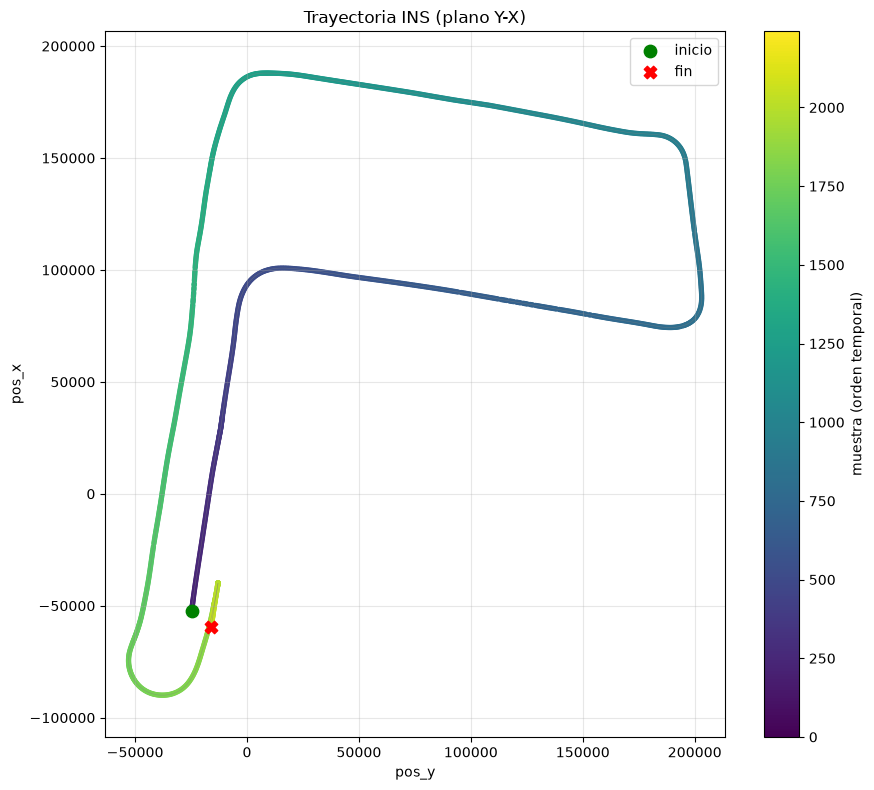

In [39]:
# Trayectoria en el plano X-Y (coloreada por tiempo)
fig, ax = plt.subplots(figsize=(9, 8))
sc = ax.scatter(df['pos_y'], df['pos_x'], c=df.index, cmap='viridis', s=8)
ax.plot(df['pos_y'], df['pos_x'], color='gray', linewidth=0.4, alpha=0.5)
ax.scatter(df['pos_y'].iloc[0], df['pos_x'].iloc[0], color='green', s=80, marker='o', label='inicio', zorder=5)
ax.scatter(df['pos_y'].iloc[-1], df['pos_x'].iloc[-1], color='red', s=80, marker='X', label='fin', zorder=5)
ax.set_xlabel('pos_y')
ax.set_ylabel('pos_x')
ax.set_title('Trayectoria INS (plano Y-X)')
ax.set_aspect('equal', adjustable='datalim')
ax.legend()
ax.grid(True, alpha=0.3)
fig.colorbar(sc, ax=ax, label='muestra (orden temporal)')
plt.tight_layout()
plt.show()

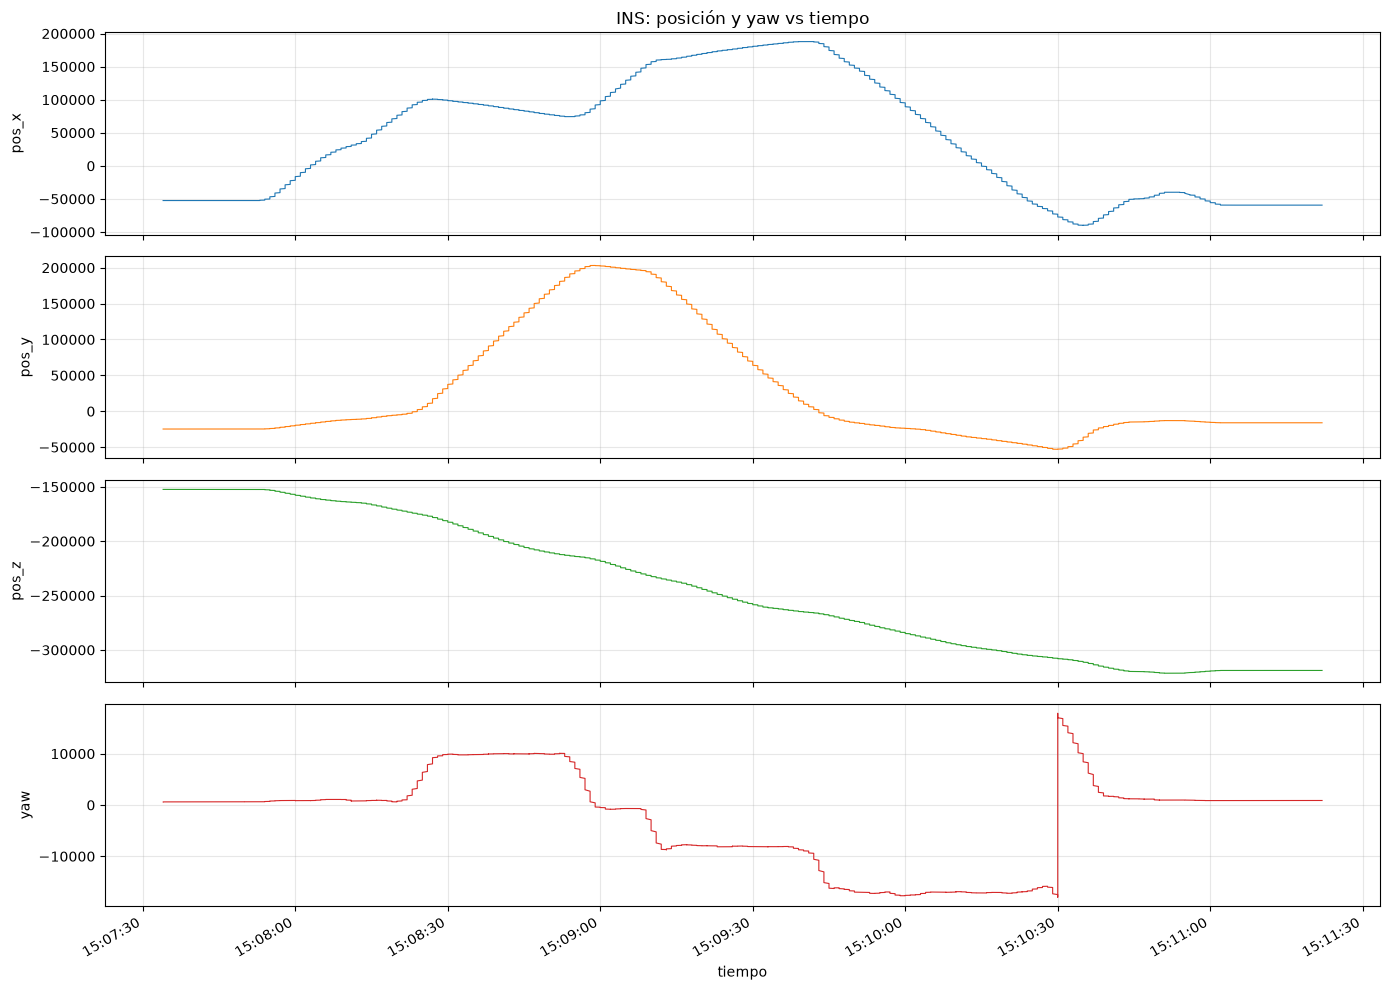

In [40]:
# Series temporales de cada componente
cols = ['pos_x', 'pos_y', 'pos_z', 'yaw']
colors = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red']
fig, axes = plt.subplots(len(cols), 1, figsize=(14, 10), sharex=True)
for ax, col, c in zip(axes, cols, colors):
    ax.plot(df['date'], df[col], color=c, linewidth=0.8)
    ax.set_ylabel(col)
    ax.grid(True, alpha=0.3)
axes[0].set_title('INS: posición y yaw vs tiempo')
axes[-1].set_xlabel('tiempo')
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

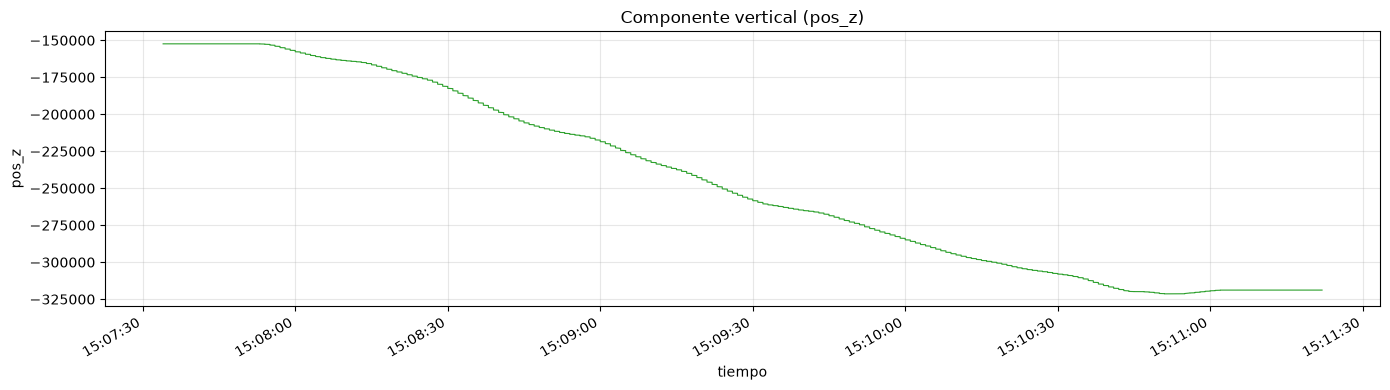

In [41]:
# Altura (pos_z) vs tiempo, en detalle
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(df['date'], df['pos_z'], color='tab:green', linewidth=0.8)
ax.set_xlabel('tiempo')
ax.set_ylabel('pos_z')
ax.set_title('Componente vertical (pos_z)')
ax.grid(True, alpha=0.3)
fig.autofmt_xdate()
plt.tight_layout()
plt.show()